In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import SGDClassifier

In [2]:
# -------------------------------
# STEP 1: Generate synthetic dataset
# -------------------------------
# Creates 200 data points grouped into 2 clusters (binary classification)
# Each point has 2 features → easy to visualize
X, y = datasets.make_blobs(
    n_samples=700,       # total number of data points
    centers=2,           # number of classes (2 → binary classification)
    random_state=42,     # ensures reproducibility
    cluster_std=3.5      # spread of clusters (higher = more overlap)
)
# -------------------------------
# STEP 2: Convert labels {0,1} → {-1,1}
# -------------------------------
# SVM requires labels in {-1, +1} form because of its mathematical formulation:
# y * (w.x + b) ≥ 1
# If labels were 0, the equation breaks (0 cancels everything)
y = np.where(y == 0, -1, 1)

# -------------------------------
# STEP 3: Train-Test Split
# -------------------------------
# Split dataset into:
# - Training set → used to train model
# - Test set → used to evaluate model performance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% data for testing
    random_state=42      # ensures same split every time
)
# -------------------------------
# STEP 4: Feature Scaling (Standardization)
# -------------------------------
# SVM depends on distances, so scaling is critical
# Without scaling → features with larger values dominate
scaler = StandardScaler()

# Fit only on training data:
# - learns mean and standard deviation
# - transforms training data
X_train = scaler.fit_transform(X_train)

# Transform test data using SAME scaling parameters
# (DO NOT fit again → prevents data leakage)
X_test = scaler.transform(X_test)

In [9]:
def plot_decision_boundary(X, y, model, title):
    plt.figure(figsize=(6,5))
    
    # Scatter plot
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', alpha=0.7)
    
    # Create grid
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contour(xx, yy, Z, levels=[0], colors='black')
    plt.title(title)
    plt.show()

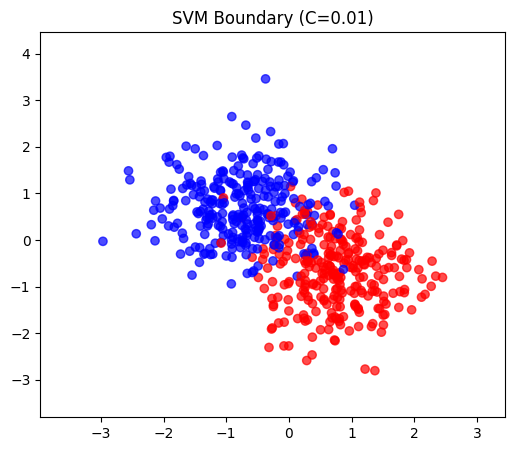

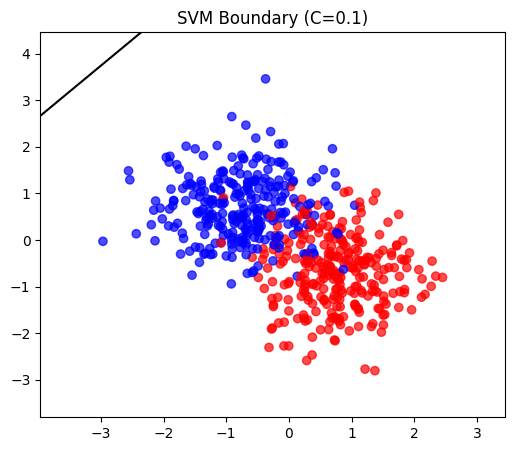

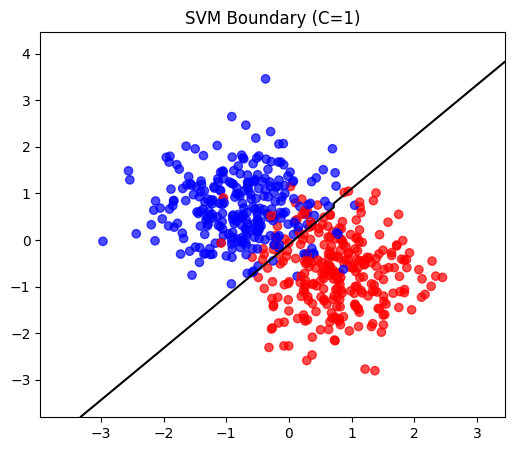

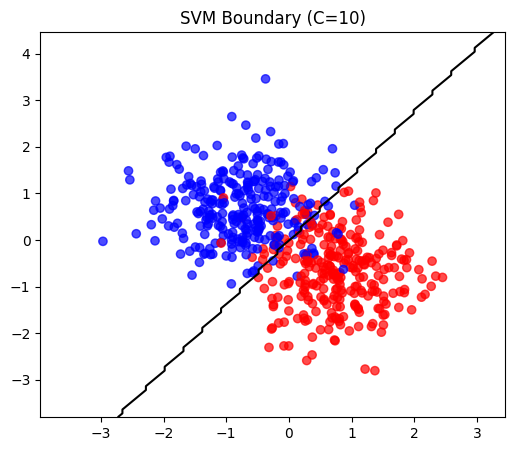

In [12]:
# -------------------------------
# STEP 1: Define different C values
# -------------------------------
# These control regularization strength
# Small C → strong regularization-> underfitting risk
# Large C → weak regularization-> overfitting risk
C_values = [0.01, 0.1, 1, 10]

# Dictionary to store trained models for each C
models = {}
# -------------------------------
# STEP 2: Train model for each C
# -------------------------------
for C in C_values:
    # Create SVM model using SGD
    # alpha = 1/C → inverse relation
    model = SGDClassifier (
        loss='hinge',     # hinge loss → SVM
        alpha=1/C,        # regularization strength
        max_iter=1000,
        random_state=42
    )
    # Train model
    model.fit(X_train, y_train)
    
    # Store model for later evaluation
    models[C] = model
    
    # -------------------------------
    # STEP 3: Visualize decision boundary
    # -------------------------------
    # Shows how boundary changes with C
    plot_decision_boundary(
        X_train,
        y_train,
        model,
        f"SVM Boundary (C={C})"
    )

In [13]:
# -------------------------------
# STEP 1: Evaluate each trained model
# -------------------------------
for C, model in models.items():
    # Predict labels for test data
    # Uses learned decision boundary: sign(w.x + b)
    y_pred = model.predict(X_test)
    
    # -------------------------------
    # STEP 2: Compute evaluation metrics
    # -------------------------------
    # Accuracy → overall correctness
    acc = accuracy_score(y_test, y_pred)
    
    # Precision → correctness of positive predictions
    # TP / (TP + FP)
    prec = precision_score(y_test, y_pred)
    
    # Recall → ability to find all positives
    # TP / (TP + FN)
    rec = recall_score(y_test, y_pred)
    
    # -------------------------------
    # STEP 3: Print results
    # -------------------------------
    print(f"\nC = {C}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)


C = 0.01
Accuracy: 0.4857142857142857
Precision: 0.4857142857142857
Recall: 1.0

C = 0.1
Accuracy: 0.4857142857142857
Precision: 0.4857142857142857
Recall: 1.0

C = 1
Accuracy: 0.9214285714285714
Precision: 0.9130434782608695
Recall: 0.9264705882352942

C = 10
Accuracy: 0.9285714285714286
Precision: 0.9142857142857143
Recall: 0.9411764705882353


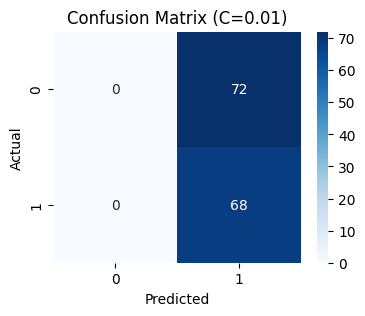

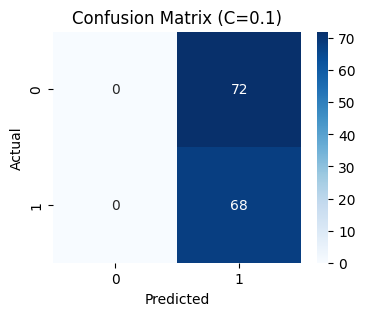

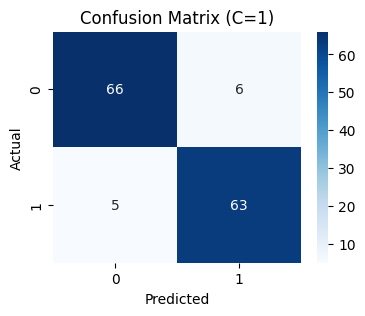

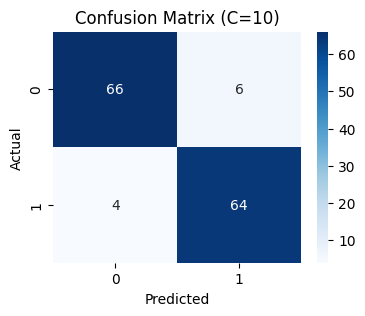

In [14]:
import seaborn as sns
# -------------------------------
# STEP 1: Loop over each trained model
# -------------------------------
for C, model in models.items():
    
    # Predict labels for test data
    y_pred = model.predict(X_test)
    
    # -------------------------------
    # STEP 2: Compute confusion matrix
    # -------------------------------
    # Structure:
    # [[TN, FP],
    #  [FN, TP]]
    cm = confusion_matrix(y_test, y_pred)
    
    # -------------------------------
    # STEP 3: Plot confusion matrix
    # -------------------------------
    plt.figure(figsize=(4,3))
    
    sns.heatmap(
        cm,
        annot=True,     # show numbers inside cells
        fmt='d',        # integer format
        cmap='Blues'    # color scheme
    )
    
    # Labels and title
    plt.title(f"Confusion Matrix (C={C})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    # Display plot
    plt.show()

